# Capacitated Warehouse Location Problem (MILP)

This notebook formulates and solves a **facility location problem** using Mixed-Integer Linear Programming (MILP) with [PuLP](https://coin-or.github.io/PuLP/).

**Problem:** Given a set of candidate warehouse locations and customer locations on a 2D plane, decide:
1. Which warehouses to open (incurring a fixed setup cost), and
2. Which warehouse serves each customer (incurring a shipping cost proportional to demand × distance)

**Objective:** Minimise total cost = fixed opening costs + total shipping costs.

In [1]:
# Install dependencies (only needed once)
# Uncomment the line below if running for the first time
# !pip install pulp numpy matplotlib

In [ ]:
import pulp
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fix random seed for reproducibility
np.random.seed(42)

# Problem parameters 
num_customers  = 25   # Number of customers (demand nodes)
num_facilities = 8    # Number of candidate warehouse locations

customers  = list(range(num_customers))
facilities = list(range(num_facilities))

# Generate random coordinates on a 100×100 grid 
customer_coords  = {i: (np.random.randint(0, 100), np.random.randint(0, 100)) for i in customers}
facility_coords  = {j: (np.random.randint(0, 100), np.random.randint(0, 100)) for j in facilities}

# Random demand per customer (units: 10–30) 
demands = {i: np.random.randint(10, 30) for i in customers}

# Random fixed opening cost per warehouse (1 000–5 000) 
fixed_costs = {j: np.random.randint(1000, 5000) for j in facilities}

# Shipping cost = demand × Euclidean distance (unit cost per distance = 1) 
# This linear cost structure can be swapped for any other distance function
# (e.g. road distance, haversine) without changing the model logic.
shipping_costs = {}
for i in customers:
    for j in facilities:
        dist = math.sqrt(
            (customer_coords[i][0] - facility_coords[j][0])**2 +
            (customer_coords[i][1] - facility_coords[j][1])**2
        )
        shipping_costs[i, j] = dist

print(f"Customers: {num_customers}  |  Candidate warehouses: {num_facilities}")
print(f"Total demand: {sum(demands.values())}")

Customers: 25  |  Candidate warehouses: 8
Total demand: 483


In [ ]:
# Build the MILP model
prob = pulp.LpProblem("Warehouse_Location_Problem", pulp.LpMinimize)

# Decision variables
# y[j] = 1 if warehouse j is opened
y = pulp.LpVariable.dicts("Open",  facilities, cat='Binary')
# x[i,j] = 1 if customer i is served by warehouse j
x = pulp.LpVariable.dicts("Serve", [(i, j) for i in customers for j in facilities], cat='Binary')

# Objective function 
total_fixed_cost    = pulp.lpSum(fixed_costs[j] * y[j] for j in facilities)
total_shipping_cost = pulp.lpSum(
    demands[i] * shipping_costs[i, j] * x[i, j]
    for i in customers for j in facilities
)
prob += total_fixed_cost + total_shipping_cost, "Total_Cost"

# Constraints 
# C1: Every customer must be assigned to exactly one warehouse
for i in customers:
    prob += pulp.lpSum(x[i, j] for j in facilities) == 1, f"Demand_Constraint_{i}"

# C2: A customer can only be assigned to an open warehouse
for i in customers:
    for j in facilities:
        prob += x[i, j] <= y[j], f"Assignment_Constraint_{i}_{j}"

print("Model built.")
print(f"  Variables   : {len(prob.variables())}")
print(f"  Constraints : {len(prob.constraints)}")

Model built.
  Variables   : 208
  Constraints : 225


In [ ]:
# Solve
prob.solve(pulp.PULP_CBC_CMD(msg=0))   # msg=0 suppresses solver log

print("Status:", pulp.LpStatus[prob.status])
print("-" * 40)

if pulp.LpStatus[prob.status] == "Optimal":
    print(f"Optimal total cost : {pulp.value(prob.objective):,.2f}")
    print(f"  Fixed costs      : {sum(fixed_costs[j] for j in facilities if y[j].varValue > 0.9):,.2f}")

    opened_warehouses = [j for j in facilities if y[j].varValue > 0.9]
    print(f"\nOpen warehouses ({len(opened_warehouses)}):")
    for j in opened_warehouses:
        print(f"  Warehouse {j}  at {facility_coords[j]}  (fixed cost: {fixed_costs[j]})")

    # Build assignment map for downstream use
    assignment = {}   # customer → warehouse
    print("\nCustomer assignments:")
    for i in customers:
        for j in facilities:
            if x[i, j].varValue > 0.9:
                assignment[i] = j
                print(f"  Customer {i:2d}  (demand: {demands[i]:2d})  →  Warehouse {j}")
else:
    print("No optimal solution found.")

Status: Optimal
----------------------------------------
Optimal total cost : 17,815.26
  Fixed costs      : 4,614.00

Open warehouses (2):
  Warehouse 6  at (70, 43)  (fixed cost: 3235)
  Warehouse 7  at (7, 46)  (fixed cost: 1379)

Customer assignments:
  Customer  0  (demand: 12)  →  Warehouse 6
  Customer  1  (demand: 23)  →  Warehouse 7
  Customer  2  (demand: 26)  →  Warehouse 6
  Customer  3  (demand: 13)  →  Warehouse 6
  Customer  4  (demand: 27)  →  Warehouse 6
  Customer  5  (demand: 17)  →  Warehouse 6
  Customer  6  (demand: 13)  →  Warehouse 7
  Customer  7  (demand: 11)  →  Warehouse 7
  Customer  8  (demand: 15)  →  Warehouse 7
  Customer  9  (demand: 19)  →  Warehouse 7
  Customer 10  (demand: 13)  →  Warehouse 7
  Customer 11  (demand: 27)  →  Warehouse 6
  Customer 12  (demand: 21)  →  Warehouse 7
  Customer 13  (demand: 11)  →  Warehouse 6
  Customer 14  (demand: 19)  →  Warehouse 6
  Customer 15  (demand: 13)  →  Warehouse 6
  Customer 16  (demand: 23)  →  Warehous

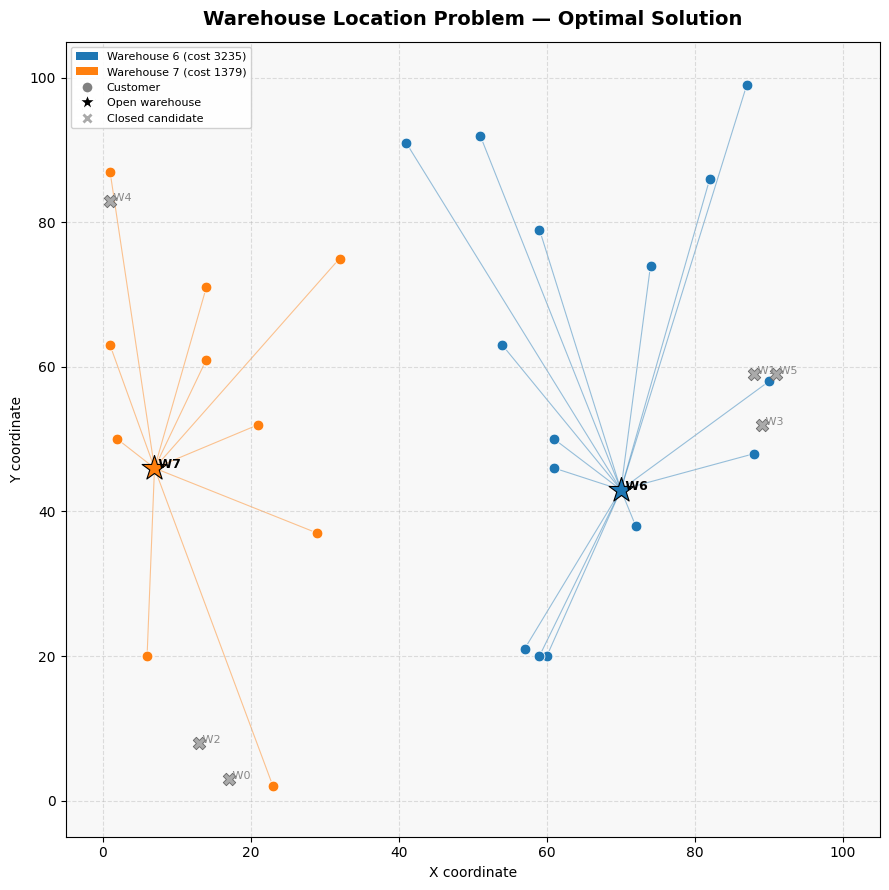

Figure saved to warehouse_solution.png


In [ ]:
# Visualisation 
# Assign a distinct colour to each open warehouse for its served customers
COLORS = plt.cm.tab10.colors
warehouse_color = {j: COLORS[k % len(COLORS)] for k, j in enumerate(opened_warehouses)}

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.set_facecolor("#f8f8f8")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("Warehouse Location Problem — Optimal Solution", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

# Draw assignment lines (customer → its warehouse)
for i in customers:
    j = assignment[i]
    cx, cy = customer_coords[i]
    wx, wy = facility_coords[j]
    ax.plot([cx, wx], [cy, wy],
            color=warehouse_color[j], linewidth=0.8, alpha=0.45, zorder=1)

# Plot customers (coloured by their assigned warehouse)
for i in customers:
    j = assignment[i]
    cx, cy = customer_coords[i]
    ax.scatter(cx, cy, color=warehouse_color[j],
               s=60, edgecolors="white", linewidths=0.6, zorder=3)

# Plot candidate warehouses (closed = grey X, open = coloured star)
for j in facilities:
    wx, wy = facility_coords[j]
    if j in opened_warehouses:
        ax.scatter(wx, wy, marker="*", s=350,
                   color=warehouse_color[j],
                   edgecolors="black", linewidths=0.8, zorder=5)
        ax.annotate(f" W{j}", (wx, wy), fontsize=9, fontweight="bold", zorder=6)
    else:
        ax.scatter(wx, wy, marker="X", s=80,
                   color="#aaaaaa", edgecolors="#666666", linewidths=0.6, zorder=4)
        ax.annotate(f" W{j}", (wx, wy), fontsize=8, color="#888888", zorder=6)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=warehouse_color[j], label=f"Warehouse {j} (cost {fixed_costs[j]})") 
    for j in opened_warehouses
]
legend_elements += [
    plt.Line2D([0], [0], marker='o',  color='w', markerfacecolor='grey', markersize=8, label='Customer'),
    plt.Line2D([0], [0], marker='*',  color='w', markerfacecolor='black', markersize=12, label='Open warehouse'),
    plt.Line2D([0], [0], marker='X',  color='w', markerfacecolor='#aaaaaa', markersize=8,  label='Closed candidate'),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("warehouse_solution.png", dpi=150)
plt.show()
print("Figure saved to warehouse_solution.png")